## Tool Calling in LangGraph

This notebook builds a tool-using chatbot: a graph in which the LLM node can decide, on its own, to invoke external functions (tools) instead of answering directly, and the results of those calls are fed back into the conversation before the LLM produces its final answer. This is the core mechanism behind agentic behavior in LangGraph.

### What a tool is

A tool is any callable (a Python function, or a pre-built integration such as a search wrapper) that is exposed to the LLM with a name, a description, and an argument schema. The LLM does not execute the tool itself. Instead, when it decides a tool is needed, it emits a structured "tool call" — a JSON object naming the tool and its arguments — inside its response message. The graph is then responsible for detecting that request, actually running the Python function, and returning the result to the LLM as a new message.

### How tool schemas are generated

When a plain Python function is decorated with `@tool` (from `langchain_core.tools`), LangChain introspects the function to build the schema the LLM sees:

- The function name becomes the tool name.
- The type hints on each parameter (e.g. `first_num: float`, `symbol: str`) become the JSON-schema types for the arguments.
- The docstring becomes the tool's description, which is what the LLM reads to decide when and how to use the tool.

This means the docstring is not just documentation — it is functionally part of the API contract the LLM relies on to choose and call the tool correctly.

### Binding tools to the LLM

`llm.bind_tools(tools)` attaches the list of tool schemas to the model, producing a new runnable (`llm_with_tools`) that, on each invocation, may return either a normal text response or a response containing one or more tool calls. The underlying model itself never runs the tools; it only ever emits requests to run them.

### The ToolNode and the agent loop

`ToolNode(tools)` is a prebuilt LangGraph node that inspects the latest AI message for tool calls, executes the corresponding Python functions with the arguments the LLM supplied, and appends the results back into the message list as `ToolMessage` objects.

`tools_condition` is a prebuilt conditional-edge function that looks at the LLM's latest output: if it contains tool calls, routing goes to the `ToolNode`; if not, routing goes to `END`. Wiring `chat_node -> (tools_condition) -> tools -> chat_node` creates a loop: the LLM can request a tool, receive the result, and then either request another tool or produce a final answer. This LLM-node/tool-node loop is the foundational pattern for agentic workflows in LangGraph, and everything downstream (multi-tool chains, RAG retrieval as a tool, MCP-exposed tools) is a variation on this same loop.


In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

import requests
import random

### Imports

This cell brings in everything the rest of the notebook needs:

- `StateGraph`, `START`, `END` from `langgraph.graph` — the graph builder and its entry/exit markers.
- `TypedDict`, `Annotated` — for defining the graph's state schema.
- `BaseMessage`, `HumanMessage` from `langchain_core.messages` — the message types that flow through the graph.
- `ChatOpenAI` — the LLM wrapper that will be given tools.
- `add_messages` — the reducer used to append new messages to state instead of overwriting the list.
- `load_dotenv` — loads API keys (OpenAI, etc.) from a `.env` file.
- `ToolNode`, `tools_condition` from `langgraph.prebuilt` — the prebuilt tool-execution node and the routing function that decide whether to call a tool or finish.
- `DuckDuckGoSearchRun` — a ready-made web-search tool from `langchain_community`.
- `tool` from `langchain_core.tools` — the decorator used to turn plain functions into LLM-callable tools.
- `requests`, `random` — standard libraries used inside the custom tools (HTTP calls for the stock-price tool).


In [2]:
load_dotenv()

True

### Loading environment variables

`load_dotenv()` reads a local `.env` file and populates the process environment with the credentials the LLM and tools need at runtime (for example the OpenAI API key). The tool calls made further down (`get_stock_price`) also embed an API key directly in the URL, but the LLM itself is authenticated through the environment variables loaded here. A return value of `True` confirms a `.env` file was found and loaded.


In [3]:
llm = ChatOpenAI()

### Instantiating the base LLM

`llm = ChatOpenAI()` creates the plain chat model, with no tools attached yet. At this stage it behaves like an ordinary chat model: it can only produce text, and has no way to request tool execution. Tool awareness is added explicitly in a later cell via `bind_tools`, which keeps the concerns of "what is the model" and "what can the model call" separate.


In [5]:
# Tools
search_tool = DuckDuckGoSearchRun(region="us-en")

@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """
    Perform a basic arithmetic operation on two numbers.
    Supported operations: add, sub, mul, div
    """
    try:
        if operation == "add":
            result = first_num + second_num
        elif operation == "sub":
            result = first_num - second_num
        elif operation == "mul":
            result = first_num * second_num
        elif operation == "div":
            if second_num == 0:
                return {"error": "Division by zero is not allowed"}
            result = first_num / second_num
        else:
            return {"error": f"Unsupported operation '{operation}'"}
        
        return {"first_num": first_num, "second_num": second_num, "operation": operation, "result": result}
    except Exception as e:
        return {"error": str(e)}


@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=C9PE94QUEW9VWGFM"
    r = requests.get(url)
    return r.json()


### Defining the tools

Three tools are made available in this notebook:

- `search_tool = DuckDuckGoSearchRun(region="us-en")` — a prebuilt LangChain community tool that performs a live DuckDuckGo web search and returns text results. Its schema and description come from the library itself, not from a docstring written here.

- `calculator` — a custom tool decorated with `@tool`. Its signature `(first_num: float, second_num: float, operation: str) -> dict` tells the LLM it must supply two numbers and an operation string. Its docstring, `"Perform a basic arithmetic operation on two numbers. Supported operations: add, sub, mul, div"`, is what the LLM reads to know both what the tool does and which literal strings are valid for `operation`. Internally it branches on `operation`, guards against division by zero, and returns a dict describing either the computed `result` or an `error` key — returning structured errors rather than raising lets the LLM see the failure as a normal tool result and react to it (e.g. by trying a different operation) instead of the graph crashing.

- `get_stock_price` — a custom tool with signature `(symbol: str) -> dict`. Its docstring explains it fetches the latest price for a ticker symbol via the Alpha Vantage `GLOBAL_QUOTE` endpoint. It builds the request URL with the given `symbol` and a hardcoded API key, performs a synchronous `requests.get`, and returns the parsed JSON response directly. Note that the tool performs real network I/O when invoked by the graph — the LLM only decides to call it, the `ToolNode` is what actually executes the HTTP request.

All three tools are defined here but not yet connected to the LLM or the graph — that wiring happens in the next two cells.


In [6]:
# Make tool list
tools = [get_stock_price, search_tool, calculator]

# Make the LLM tool-aware
llm_with_tools = llm.bind_tools(tools)

### Assembling the tool list and binding it to the LLM

`tools = [get_stock_price, search_tool, calculator]` collects the three tools into the single list that will be shared by both the LLM and the `ToolNode` — both must be given the same set of tools, since the `ToolNode` needs to be able to execute whichever tool name the LLM decides to call.

`llm_with_tools = llm.bind_tools(tools)` produces a new runnable that carries the tool schemas alongside the base model. Calling `llm_with_tools.invoke(...)` still returns an `AIMessage`, but that message may now contain a `tool_calls` list if the model decides one or more tools should be invoked in response to the conversation so far. The original `llm` object is left untouched; `llm_with_tools` is the tool-aware variant used inside the graph.


In [7]:
# state
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

### State schema

`ChatState` is a `TypedDict` with a single field, `messages`, typed as `Annotated[list[BaseMessage], add_messages]`. This is the standard message-state pattern used throughout the folder (equivalent in spirit to the prebuilt `MessagesState`). The `add_messages` annotation is a reducer: instead of each node returning the full message list and overwriting state, a node can return just the new message(s) it produced, and `add_messages` appends them to the existing list (matching by message id when relevant). This is what makes it possible for `chat_node` and the `ToolNode` to each contribute only their own message to a shared, growing conversation history.


In [8]:
# graph nodes
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)  # Executes tool calls

### The chat node and the tool node

`chat_node(state)` reads the current `messages` list from state, invokes `llm_with_tools` on it, and returns `{"messages": [response]}`. Because of the `add_messages` reducer, this appends the model's response — which may be a plain answer or an `AIMessage` carrying `tool_calls` — onto the existing history rather than replacing it.

`tool_node = ToolNode(tools)` builds the prebuilt tool-execution node from the same `tools` list bound to the LLM. When this node runs, it reads the most recent `AIMessage` in state, executes every tool call it finds (calling the matching Python function with the arguments the LLM supplied), and returns one `ToolMessage` per call, each tagged with the corresponding `tool_call_id` so the LLM can later see which result answers which request.


In [9]:
# graph structure
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

### Building the graph and registering nodes

`graph = StateGraph(ChatState)` creates the graph builder against the `ChatState` schema. Two nodes are registered: `"chat_node"`, bound to the `chat_node` function defined above, and `"tools"`, bound to the prebuilt `tool_node` instance. No edges exist yet — that wiring, including the conditional routing that makes this an agent loop, is added in the next cell.


In [10]:
graph.add_edge(START, "chat_node")

# If the LLM asked for a tool, go to ToolNode; else finish
graph.add_conditional_edges("chat_node", tools_condition)

graph.add_edge("tools", "chat_node")    

### Wiring the agent loop

Three edges complete the graph:

- `graph.add_edge(START, "chat_node")` — every invocation begins at the LLM node.
- `graph.add_conditional_edges("chat_node", tools_condition)` — after the LLM responds, `tools_condition` inspects the latest message. If it contains one or more tool calls, routing goes to the `"tools"` node (the prebuilt condition looks specifically for a populated `tool_calls` list, and by default routes there under the name `"tools"`, matching the node name registered above). If there are no tool calls, routing goes to `END` and the graph finishes.
- `graph.add_edge("tools", "chat_node")` — after tool results are appended to state, control always returns to the LLM node, so it can either read the tool results and answer, or issue another tool call if more information is needed.

Together these three edges form a cycle between `chat_node` and `tools`, bounded by the conditional exit to `END`. This is what allows the graph to satisfy requests that require zero, one, or several tool calls with no change to the graph structure — the number of loop iterations is decided at runtime by the LLM's own outputs.


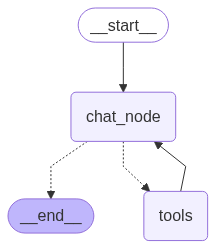

In [11]:
chatbot = graph.compile()

chatbot

### Compiling the graph

`chatbot = graph.compile()` finalizes the node and edge definitions into a runnable graph object. Rendering `chatbot` (as the second line does) displays the compiled graph's structure. From this point on, `chatbot.invoke(...)` is the single entry point used for every conversation in the remaining cells, and it will internally loop through `chat_node` and `tools` however many times a given request requires.


In [12]:
# Regular chat
out = chatbot.invoke({"messages": [HumanMessage(content="Hello!")]})

print(out["messages"][-1].content)


Hi there! How can I assist you today?


### Trace: a plain greeting, no tool call

The input is a single `HumanMessage(content="Hello!")`. Inside the graph: `chat_node` invokes `llm_with_tools`, which recognizes no tool is needed for a greeting and returns a plain `AIMessage`. `tools_condition` sees an empty `tool_calls` list and routes straight to `END`. `out["messages"][-1].content` is therefore the model's direct reply, "Hi there! How can I assist you today?" — the tool loop is present in the graph but is not exercised for this input.


In [13]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is 2*3?")]})
print(out["messages"][-1].content)

The result of 2 multiplied by 3 is 6.


### Trace: a single tool call to the calculator

For "What is 2*3?", `chat_node` invokes `llm_with_tools`, which this time determines arithmetic is required and returns an `AIMessage` whose `tool_calls` names `calculator` with arguments equivalent to `first_num=2, second_num=3, operation="mul"`. `tools_condition` detects the tool call and routes to `"tools"`. `tool_node` executes `calculator(2, 3, "mul")`, producing `{"first_num": 2, "second_num": 3, "operation": "mul", "result": 6}`, wrapped in a `ToolMessage`. Control returns to `chat_node`, which now sees the tool result in the message history and phrases the final answer, "The result of 2 multiplied by 3 is 6." — one full pass through the `chat_node -> tools -> chat_node` loop.


In [14]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is the stock price of apple")]})
print(out["messages"][-1].content)

The stock price of Apple (AAPL) is $234.07.


### Trace: a single tool call to the stock-price tool

For "What is the stock price of apple", the LLM identifies `get_stock_price` as the relevant tool and supplies `symbol="AAPL"` (inferred from "apple" even though the ticker was never mentioned in the prompt — this inference is done by the LLM, not the tool). `tool_node` executes the real HTTP request to Alpha Vantage and returns the JSON quote as a `ToolMessage`. `chat_node` then reads the numeric price out of that JSON and reports it in natural language: "The stock price of Apple (AAPL) is $234.07." Again this is exactly one iteration of the loop, but with a different tool selected based on the LLM's own interpretation of the request.


In [15]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="First find out the stock price of Apple using get stock price tool then use the calculator tool to find out how much will it take to purchase 50 shares?")]})
print(out["messages"][-1].content)

The current stock price of Apple (AAPL) is $234.07. To purchase 50 shares, it would cost $11,703.50.


### Trace: a chained, multi-tool call

This prompt explicitly instructs a two-step plan: "First find out the stock price of Apple using get stock price tool then use the calculator tool to find out how much will it take to purchase 50 shares?" This is where the loop structure actually matters:

1. `chat_node` invokes the LLM, which emits a tool call to `get_stock_price(symbol="AAPL")`. `tools_condition` routes to `"tools"`, which executes it and returns the quote (234.07) as a `ToolMessage`.
2. Control returns to `chat_node`. With the price now in context, the LLM emits a second tool call, this time to `calculator(first_num=234.07, second_num=50, operation="mul")`. `tools_condition` again routes to `"tools"`, which computes 11,703.50 and returns it as another `ToolMessage`.
3. Control returns to `chat_node` a third time. With both tool results now in the message history, the LLM has everything it needs and returns a final plain-text `AIMessage`. `tools_condition` sees no tool calls and routes to `END`.

The final content, "The current stock price of Apple (AAPL) is $234.07. To purchase 50 shares, it would cost $11,703.50.", is only reachable because the graph looped through `chat_node -> tools` twice before exiting — each tool call fed its result back into state so the next decision (which tool to call, or whether to stop) could be made with full context. This is the general pattern for any number of sequential or dependent tool calls: the graph structure never changes, only the number of loop iterations.


## Summary

This notebook demonstrates the complete tool-calling pattern in LangGraph: functions and integrations exposed as tools with LLM-readable schemas (derived from type hints and docstrings via `@tool`, or supplied directly by a prebuilt integration like `DuckDuckGoSearchRun`); an LLM bound to those tools with `bind_tools` so it can emit structured tool-call requests; a `ToolNode` that executes whatever tools the LLM requests and reports results back as `ToolMessage`s; and a conditional edge (`tools_condition`) that lets the graph decide, per turn, whether to loop back for another tool call or finish. The four invocation traces show this loop running zero, one, and two iterations without any change to the graph's structure — the LLM's own output entirely determines the control flow.

This LLM-node/tool-node cycle is the foundational agentic pattern in LangGraph. It underlies the retrieval-augmented generation notebooks in this repository, where a retriever is wrapped and invoked as a tool (or as a fixed retrieval step feeding the same kind of conditional, evaluation-driven routing) rather than a search or calculator function, and it underlies MCP-based notebooks, where tools are not defined locally with `@tool` but are instead discovered from an external MCP server and bound to the LLM in the same way. In both cases, the graph shape stays the same: an LLM decides what to call, a node executes it, and the result flows back into state to inform the next decision.
